# Trabalho Prático 2025/26 da UC de Ciência de Dados e Big Data

## Trabalho desenvolvido por:
- **Miguel Grilo | 58387**
- **Jorge Couto  | 58656**

#

## Imports

In [1]:
# Parte 1
## Fase 2
from pyspark import SparkConf, SparkContext # SparkConf define parâmetros de performance e SparkContext é a porta de entrada para a API de RDDs

## Fase 3
from pyspark.sql import SparkSession # Porta de entrada para DataFrames e Spark SQL
import pyspark.sql.functions as F # Biblioteca de funções otimizadas
from pyspark.sql.types import StructType, StructField, FloatType, IntegerType # Definição explícita de esquemas (Schemas)
import time # Medir os tempos de execução

# Parte 2
## Fase 1
### Abordagem Global
from pyspark.ml import Pipeline # Automatizar o fluxo de transformações
from pyspark.ml.feature import Imputer, VectorAssembler # Pré-processamento e vetorização de features
from pyspark.ml.classification import DecisionTreeClassifier # Algoritmo de DT para execução global
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder # Otimização de hiperparâmetros
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, RegressionEvaluator # Métricas de performance
### Abordagem Local
import pandas as pd # Manipulação de dados em memória dentro de cada worker
from sklearn.tree import DecisionTreeClassifier as SklearnDT # Algoritmo de DT para execução local
from statistics import multimode # Agregação de votos
from pyspark.sql import Row # Converter resultados de volta ao formato Spark após o processamento local
import numpy as np # Manipulação de dados em memória dentro de cada worker

## Fase 2
import matplotlib.pyplot as plt # Gráficos dos testes de escalabilidade

#

# Parte 1

## Fase 1: Escolha e Justificação do Dataset

### Escolha do Dataset

O dataset **Give Me Some Credit** foca-se no papel vital dos bancos e no acesso ao crédito, desafiando a melhoria de algoritmos de credit scoring para prever a probabilidade de dificuldades financeiras nos próximos dois anos. Com dados históricos de **150 mil requerentes de crédito**, o seu Volume beneficia significativamente do processamento paralelo e distribuído para otimizar a modelação preditiva.

#### Link do Dataset : [Give Me Some Credit](https://www.kaggle.com/competitions/GiveMeSomeCredit/data?select=cs-training.csv)

### Descrição das Features

O objetivo deste dataset é construir modelos que consigam prever se um indivíduo entrar em dificuldades financeiras graves nos próximos dois anos.

- **SeriousDlqin2yrs &rightarrow; `Label`(Variável Alvo):**
  - Indica se a pessoa teve um atraso no pagamento de 90 dias ou mais (incumprimento grave) nos últimos 2 anos.
  - Sim/Não (`Binário`: 0 ou 1).

- **RevolvingUtilizationOfUnsecuredLines &rightarrow; `Tx_Utilizacao`:**
  - O saldo total em cartões de crédito e linhas de crédito pessoais dividido pela soma dos limites de crédito. Essencialmente, é a percentagem do limite de crédito disponível que a pessoa está a utilizar.
  - Percentagem (`Float`).

- **age &rightarrow; `Idade`:**
  - A idade do requerente de crédito em anos.
  - `Inteiro`.

- **NumberOfTime30-59DaysPastDueNotWorse &rightarrow; `Atraso_30_59`:**
  - O número de vezes que o requerente de crédito teve um atraso de pagamento entre 30 e 59 dias nos últimos 2 anos.
  - `Inteiro`.

- **DebtRatio &rightarrow; `Tx_Endividamento`:**
  - A taxa de endividamento. Calcula-se somando os pagamentos mensais de dívidas, pensão de alimentos e custos de vida, e dividindo pelo rendimento mensal bruto.
  - Percentagem (`Float`).

- **MonthlyIncome &rightarrow; `Rendimento`:**
  - O rendimento mensal do requerente de crédito.
  - Real (`Float`).

- **NumberOfOpenCreditLinesAndLoans &rightarrow; `LC_Abertas`:**
  - O número de empréstimos abertos e linhas de crédito do requerente de crédito.
  - `Inteiro`.

- **NumberOfTimes90DaysLate &rightarrow; `Atraso_90`:**
  - O número de vezes que o requerente de crédito teve um atraso de pagamento de 90 dias ou mais (incumprimento grave).
  - `Inteiro`.

- **NumberRealEstateLoansOrLines &rightarrow; `Emp_Imb`:**
  - O número de empréstimos imobiliários em nome do requerente de crédito.
  - `Inteiro`.

- **NumberOfTime60-89DaysPastDueNotWorse &rightarrow; `Atraso_60_89`:**
  - O número de vezes que o requerente de crédito teve um atraso de pagamento entre 60 e 89 dias nos últimos 2 anos.
  - `Inteiro`.

- **NumberOfDependents &rightarrow; `Dependentes`:**
  - O número de dependentes na família.
  - `Inteiro`, porém será inicialmente definido como `Float` para ser trabalhado no `Imputer`.

### Justificação e Adequação ao Apache Spark

Para o conjunto de dados em estudo, a justificação fundamenta-se nos **5 V's de Big Data**:

- **`Volume:`** O dataset possui 150 mil instâncias e múltiplas features, o que o torna suficientemente grande para tornar o processamento tradicional ineficiente, exigindo processamento distribuído, uma vez que operações tornam-se computacionalmente dispendiosas em ambientes tradicionais. Assim, o Apache Spark permite escalar estas operações de forma eficiente, explorando paralelismo e computação em memória.

- **`Velocidade:`** No setor bancário, o risco de crédito exige respostas em milissegundos. Embora este dataset seja estático, ele simula o tipo de dados processados em pipelines de análise em tempo real.

- **`Variedade:`** O dataset combina diferentes tipos de informação financeira estruturada: indicadores de utilização de crédito (percentagens), dados demográficos (idade/dependentes) e histórico de comportamento (contagens de atrasos).

- **`Veracidade:`** O dataset apresenta desafios reais de qualidade onde a coluna `Rendimento Mensal` possui milhares de valores nulos e a `Taxa de Endividamento` contém outliers extremos devido a inconsistências metodológicas no cálculo da taxa onde o rendimento zero distorce o cálculo. Tratar estas imperfeições de forma distribuída justifica o uso do Spark para garantir que a limpeza de dados seja robusta antes da fase de modelação.

- **`Valor:`** O valor reside na capacidade preditiva de minimizar o risco financeiro. Prever a probabilidade de insolvência permite às instituições bancárias reduzir perdas por incumprimento e otimizar a concessão de crédito, demonstrando como o processamento de grandes volumes de dados se traduz diretamente em vantagem económica e suporte à decisão.

A escolha deste dataset é, portanto, adequada ao princípio "Divide-and-Conquer", permitindo aplicar as ferramentas de processamento paralelo estudadas. Sendo particularmente adequado ao Apache Spark visto que o seu volume beneficia de processamento distribuído e computação em memória, a variedade de dados estruturados e problemas de qualidade é bem suportada por RDDs e DataFrames e permite aplicar MapReduce, Spark SQL e algoritmos de Machine Learning.

#

## Fase 2: Processamento e Transformação com Spark RDDs

### Carregar os dados em RDDs

Iniciamos a **Fase 2** do trabalho recorrendo à **SparkSession** como interface unificada. Esta abordagem permite-nos gerir de forma coesa tanto os **Spark RDDs** como os **DataFrames**. O ponto de entrada foi configurado para operar em **modo local**, utilizando **todos os núcleos disponíveis** (`local[*]`), de modo a garantir o paralelismo total do hardware durante a manipulação dos dados.

In [2]:
# Inicialização da SparkSession
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Trabalho_Pratico_CDBD_58387_58656") \
    .getOrCreate()

# Obter o Ponto de Entrada (sc) a partir da sessão já criada
sc = spark.sparkContext
sc.setLogLevel("ERROR") # Reduzimos a quantidade de warnings em display

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:24:08 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:24:08 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:24:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Em seguida, o carregamento do dataset é realizado recorrendo à configuração **padrão do Apache Spark** (2 partições), sem especificação explícita do número de partições. A execução de uma ação (`count`) permite validar o correto carregamento dos **150 mil registos** e identificar o número de partições iniciais atribuídas automaticamente pelo motor de execução, confirmando a estrutura base do RDD para as etapas subsequentes de limpeza e transformação.

O particionamento inicial, determinado pelo Spark em função do ambiente de execução local, serve como ponto de partida para a análise do impacto do número de partições no desempenho do processamento distribuído. Embora o sistema disponha de **14 núcleos físicos e 20 processadores lógicos**, a escolha do número de partições é posteriormente avaliada de forma experimental, tendo em conta o equilíbrio entre paralelismo e overhead de orquestração, de modo a adequar a configuração às características efetivas do dataset e das operações realizadas.

In [3]:
raw_rdd = sc.textFile("data/cs-training.csv")
# Uso de count() para forçar a ação
print(f"Total de registos carregados: {raw_rdd.count()} \nPartições iniciais: {raw_rdd.getNumPartitions()}")
raw_rdd.take(2)

Total de registos carregados: 150001 
Partições iniciais: 2


[',SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents',
 '1,1,0.766126609,45,2,0.802982129,9120,13,0,6,0,2']

### Demonstração de Particionamento

In [4]:
pct = [1, 2, 4, 8 , 10, 12, 16, 20]

pct_list = []
pct_results = []
# Testa todos os números de partições definidos
for i in pct:
    pct_list.append(i)
    pct_test = raw_rdd.repartition(i)
    start = time.time()
    pct_test.count()
    t = time.time() - start
    
    pct_results.append(t)

df_pct_test = pd.DataFrame({
    "Partições": pct_list,
    "Tempo": pct_results
}).set_index("Partições")
display(df_pct_test)

,Tempo
Partições,
1,0.549176
2,0.284139
4,0.446217
8,0.438596
10,0.502335
12,0.541717
16,0.568383
20,0.645383


O impacto do número de partições foi avaliado variando-se o particionamento entre 1 e 20 partições, recorrendo à operação `repartition()` para garantir redistribuição efetiva dos dados. Dado o dataset relativamente pequeno a ser trabalhado, observou-se que o **menor tempo de execução ocorre com 2 partições**, enquanto o **aumento progressivo do número de partições conduz a uma degradação do desempenho**. Este comportamento explica-se pelo overhead associado ao shuffle e à gestão de múltiplas tasks, que domina o tempo de execução para datasets de média dimensão, tornando o paralelismo adicional ineficaz.

Assim, embora o hardware disponibilize 20 processadores lógicos, os testes experimentais demonstraram que, para este volume de dados, o custo de orquestração e de shuffle associado ao aumento do número de partições supera os ganhos do paralelismo. **Optando então por utilizar 2 partições**, que apresentaram o menor tempo de execução nos testes realizados.

In [5]:
print(f"Número de Partições a Utilizar: {raw_rdd.getNumPartitions()}")

Número de Partições a Utilizar: 2


### Limpeza, Pré-Processamento, Transformação e Enriquecimento dos Dados

A **Limpeza** é realizada inicialmente através da transformação `filter`, que remove a linha de cabeçalho. Ao contrário de uma abordagem de remoção drástica, optou-se por preservar ao máximo os dados (mantendo as 150.000 instâncias), tratando a **Veracidade** através da identificação de valores `'NA'` e a sua posterior conversão para `None`. Esta estratégia é fundamental para garantir que o dataset mantém a sua escala para os testes de performance, evitando o enviesamento que a eliminação de quase 20% dos dados (29.731 nulos em rendimento) causaria.

O **Pré-Processamento** ocorre na função `parse_line`, aplicada ao RDD através da operação `map`. Nesta etapa, a lógica de indexação ignora a coluna de `ID`, capturando apenas as variáveis relevantes. Esta exclusão é deliberada, uma vez que identificadores únicos não possuem valor preditivo e a sua remoção evita que o modelo aprenda padrões desnecessários e possivelmente negativos para o seu desempenho. Foi implementada uma lógica de **Normalização de Outliers** para a `Tx_Endividamento`: identificou-se que valores inteiros ou superiores a 5.0 representavam inconsistências (valores absolutos da dívida em vez de percentagem), sendo estes limitados para 5.0. Esta transformação garante a estabilidade estatística necessária para algoritmos sensíveis a escalas, como as Árvores de Decisão.

O **Enriquecimento e Imputação** ocorrem na transição para DataFrame. Utilizou-se o estimador `Imputer` do Spark MLlib para preencher as lacunas no `Rendimento` e `Dependentes` utilizando a **mediana**. Dada a elevada ausência de dados no Rendimento que sugere uma limitação na recolha de dados sensíveis, justifica-se a escolha da mediana (imputação robusta) em vez da média, para evitar o enviesamento por valores extremos (outliers). Este processo transforma dados omissos em informação útil, baseada na distribuição central da amostra. A variável alvo (`Label`) é posicionada estrategicamente no final do registo, facilitando a posterior vetorização.

Para o motor do Spark, estas transformações no RDD são tratadas como "caixas negras", uma vez que a lógica Python interna não é visível ao otimizador **Catalyst**. Contudo, ao converter o RDD para DataFrame para a fase de imputação, o Spark consegue otimizar o plano de execução físico. Todas as dependências são registadas no grafo de **Lineage**, garantindo resiliência e tolerância a falhas em todo o cluster, visto que se um worker falhar durante a transformação do RDD, o Spark usa este grafo para recomputar apenas a partição perdida sem ter de reiniciar todo o trabalho.

#### Limpeza de Estrutura

In [6]:
# Remove o Header
header = raw_rdd.first()
no_header_rdd = raw_rdd.filter(lambda line: line != header)
print(f"Total de Registos após a Remoção do 'Header': {no_header_rdd.count()} instâncias\n")

Total de Registos após a Remoção do 'Header': 150000 instâncias



#### Pré-Processamento e Normalização (Nível RDD)

In [7]:
def parse_line(line):
    fields = line.split(',')
    
    # Função auxiliar para tratar "NA" ou campos vazios
    def clean(valor, tipo):
        if valor == 'NA' or valor == '' or valor is None:
            return None
        else: return tipo(valor)
    
    # Pré-processamento: Conversão de tipos e seleção de colunas relevantes (índices 1 a 11)
    # A coluna 0 (ID) é ignorada.
    
    Label                    = clean(fields[1], int)    # Variável Alvo
    Tx_Utilizacao            = clean(fields[2], float)  # Taxa de Utilização
    Idade                    = clean(fields[3], int)
    Atraso_30_59             = clean(fields[4], int)
    raw_Tx_Endividamento     = fields[5]
    Tx_Endividamento         = clean(fields[5], float)  # Taxa de Endividamento
    Rendimento               = clean(fields[6], float)  # Rendimento Mensal
    LC_Abertas               = clean(fields[7], int)    # Linhas de Crédito Abertas
    Atraso_90                = clean(fields[8], int)
    Emp_Imb                  = clean(fields[9], int)    # Empréstimos Imobiliários
    Atraso_60_89             = clean(fields[10], int)
    Dependentes              = clean(fields[11], float)
    # Dependentes definido como 'float' apenas para compatibilidade futura com MLlib e Imputer
    
    if Tx_Endividamento is not None:
        # Verifica se o valor original no CSV não tem ponto (era um Inteiro)
        if "." not in raw_Tx_Endividamento or Tx_Endividamento > 5.0:
            Tx_Endividamento = 5.0
    
    return (Tx_Utilizacao, Idade, Atraso_30_59, Tx_Endividamento, 
            Rendimento, LC_Abertas, Atraso_90, 
            Emp_Imb, Atraso_60_89, Dependentes, 
            Label)

In [8]:
# Transformação do RDD em RDD estruturado e algum pré-processamento
parsed_rdd = no_header_rdd.map(parse_line).cache()
print(f"Total de Registos Após Parsing: {parsed_rdd.count()} instâncias")

Total de Registos Após Parsing: 150000 instâncias


#### Enriquecimento/Transformação e Imputação de Dados (Nível DataFrame)

In [9]:
# Converter RDD para DataFrame
df = parsed_rdd.toDF(["Tx_Utilizacao", "Idade", "Atraso_30_59", "Tx_Endividamento", 
                   "Rendimento", "LC_Abertas", "Atraso_90", "Emp_Imb", 
                   "Atraso_60_89", "Dependentes", "Label"])

# Contagem de missings
null_count = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
]).first().asDict()
# Imprimir apenas as colunas com falhas
print("Colunas com Missings (None):")
for col_name, count in null_count.items():
    if count > 0:
        print(f"-> {col_name}: {count} valores nulos")

# Garantir que as colunas são numéricas (essencial para o Imputer)
df = df.withColumn("Rendimento", F.col("Rendimento").cast("float"))
df = df.withColumn("Dependentes", F.col("Dependentes").cast("float"))

# Configurar o Imputer
imputer = Imputer(
    inputCols=["Rendimento", "Dependentes"],
    outputCols=["Rendimento", "Dependentes"],
    strategy="median"
)

# Aplicar o Imputer
df = imputer.fit(df).transform(df)
# Volta a transformar a coluna Dependentes em int após o Imputer terminar
df = df.withColumn("Dependentes", F.col("Dependentes").cast("int"))

Colunas com Missings (None):
-> Rendimento: 29731 valores nulos
-> Dependentes: 3924 valores nulos


In [10]:
# Confirmação
print("\nConfirmação de Missings após o Imputer:")
df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) 
    for c in ["Rendimento", "Dependentes"]
]).show()


Confirmação de Missings após o Imputer:
+----------+-----------+
|Rendimento|Dependentes|
+----------+-----------+
|         0|          0|
+----------+-----------+



In [11]:
# Contagem total de missings
missings = null_count['Rendimento'] + null_count['Dependentes']
total = parsed_rdd.count()
percentagem = round((missings/total) * 100, 2)
print(f"Missings Corrigidos no Dataset: {missings} ({percentagem}%)")

Missings Corrigidos no Dataset: 33655 (22.44%)


#### Finalização e Reversão para RDD

In [12]:
# Converte cada Row num tuplo de valores tal como anteriormente
processed_rdd = df.rdd.map(lambda row: tuple(row))
print(f"Total de Registos Após Todo o Processamento do Dataset: {processed_rdd.count()} instâncias")

Total de Registos Após Todo o Processamento do Dataset: 150000 instâncias


In [13]:
processed_rdd.take(2)

[(0.766126609, 45, 2, 0.802982129, 9120.0, 13, 0, 6, 0, 2, 1),
 (0.957151019, 40, 0, 0.121876201, 2600.0, 4, 0, 0, 0, 1, 0)]

### Demonstração de Cache

Foi utilizada `cache` para persistir o RDD em memória, de modo a evitar recomputações e os I/O de disco. **O uso de `cache` é particularmente relevante uma vez que o mesmo RDD é reutilizado em múltiplas ações, evitando recomputações do grafo de lineage**. Esta persistência **facilita a tarefa seguinte de `MapReduce`**, garantindo acesso imediato aos dados já transformados e enriquecidos.

In [14]:
# Guardamos em memória porque este RDD será usado na tarefa MapReduce
processed_rdd.cache()
print(f"Total de Registos Limpos: {processed_rdd.count()}") # Dispara a ação e força a materializar a cache

Total de Registos Limpos: 150000


### Tarefa MapReduce

Em seguida, é realizada uma tarefa de **MapReduce** para analisar a taxa de incumprimento por faixa etária. Utiliza-se a transformação `map` para organizar os dados em pares chave-valor, onde a chave é a faixa etária e o valor é um tuplo contendo o indicador de incumprimento e o contador unitário (incumprimento, 1).

A operação `reduceByKey` realiza a agregação distribuída, somando os casos de incumprimento e o total de clientes por cada chave etária. A eficiência desta etapa é garantida pelo uso prévio de cache, que permite ao Spark aceder aos dados transformados diretamente na memória, evitando a recomputação do grafo de linhagem e acessos lentos ao disco.

Esta análise identifica padrões de risco geracionais e tendências de comportamento financeiro, fornecendo uma visão crucial para a segmentação de clientes e políticas de crédito. Através do pós-processamento com `mapValues`, calcula-se a taxa de probabilidade de insolvência para cada grupo, permitindo observar, por exemplo, se faixas etárias mais jovens apresentam maior risco relativo.

**Nota:** A lógica de agrupamento utiliza a operação de divisão inteira para categorizar os clientes (ex: todos os indivíduos com idades entre 30 e 39 anos são agrupados na mesma "bin"), simplificando a complexidade dos dados originais para uma interpretação estatística mais clara.

In [15]:
# Função para criar faixas etárias
def age_bin(age):
    decada = int(age) // 10
    start = decada * 10
    end = start + 9
    return f"{start}-{end}"

In [16]:
indice_Idade = 1
indice_Label = 10

tarefa_map_reduce = (
    processed_rdd
    # MAP: criar par (faixa_etária, (n_incumprimentos, 1))
    .map(lambda r: (age_bin(r[indice_Idade]), (int(r[indice_Label]), 1)))
    # REDUCE: somar pares (soma_incumprimentos, n_clientes)
    .reduceByKey(lambda x, y: (x[0] + y[0], x[1] + y[1]))
    # POST-PROCESS: calcular taxa
    .mapValues(lambda s: {
        "n_incumprimentos": s[0],
        "total": s[1],
        "taxa": s[0] / s[1] if s[1] > 0 else 0.0
    })
)

# Ordenar por início da faixa etária
ordenados = tarefa_map_reduce.sortBy(lambda key_value: int(key_value[0].split('-')[0]))

for faixa, stats in ordenados.collect():
    print(f"{faixa}\t -> incumprimentos: {stats['n_incumprimentos']}/{stats['total']} \t(taxa={stats['taxa']:.1%})")

0-9	 -> incumprimentos: 0/1 	(taxa=0.0%)
20-29	 -> incumprimentos: 1035/8820 	(taxa=11.7%)
30-39	 -> incumprimentos: 2335/23183 	(taxa=10.1%)
40-49	 -> incumprimentos: 2878/34377 	(taxa=8.4%)
50-59	 -> incumprimentos: 2278/35301 	(taxa=6.5%)
60-69	 -> incumprimentos: 1050/28905 	(taxa=3.6%)
70-79	 -> incumprimentos: 331/13601 	(taxa=2.4%)
80-89	 -> incumprimentos: 105/5125 	(taxa=2.0%)
90-99	 -> incumprimentos: 13/674 	(taxa=1.9%)
100-109	 -> incumprimentos: 1/13 	(taxa=7.7%)


Os dados revelam que a faixa dos 20-29 anos apresenta o maior risco relativo (11.7%), enquanto os grupos entre 70-99 anos são os mais estáveis financeiramente.

#

## Fase 3: Análise Estruturada com Spark SQL e DataFrames

### Conversão de RDD para DataFrame

Inicia-se agora a **Fase 3** recorrendo à `SparkSession` inicial.

Define-se um schema `explícito` através da estrutura `StructType` para a conversão do RDD em DataFrame. Esta prática é fundamental em cenários de Big Data, pois **evita que o Spark tenha de realizar uma passagem adicional sobre os dados para inferir os tipos de cada coluna**. Ao fornecer o esquema diretamente, reduzimos o custo computacional de I/O, poupamos tempo de processamento e garantimos a integridade dos dados.

Esta definição permite ainda que os motores **Catalyst** (otimizador de consultas) e **Tungsten** (gestor de memória) operem com máxima eficiência, uma vez que conhecem antecipadamente o layout físico dos dados. O **caching** em memória e a subsequente ação `show()` validam a estrutura final, assegurando que o dataset está pronto para os algoritmos de aprendizagem automática.

In [17]:
# Definição do Esquema
schema = StructType([
    StructField("Tx_Utilizacao", FloatType(), True),
    StructField("Idade", IntegerType(), True),
    StructField("Atraso_30_59", IntegerType(), True),
    StructField("Tx_Endividamento", FloatType(), True),
    StructField("Rendimento", FloatType(), True),
    StructField("LC_Abertas", IntegerType(), True),
    StructField("Atraso_90", IntegerType(), True),
    StructField("Emp_Imb", IntegerType(), True),
    StructField("Atraso_60_89", IntegerType(), True),
    StructField("Dependentes", IntegerType(), True),
    StructField("Label", IntegerType(), True) # Variável Alvo
])

In [18]:
# Conversão
df = spark.createDataFrame(processed_rdd, schema).cache()
df.show(2)

+-------------+-----+------------+----------------+----------+----------+---------+-------+------------+-----------+-----+
|Tx_Utilizacao|Idade|Atraso_30_59|Tx_Endividamento|Rendimento|LC_Abertas|Atraso_90|Emp_Imb|Atraso_60_89|Dependentes|Label|
+-------------+-----+------------+----------------+----------+----------+---------+-------+------------+-----------+-----+
|   0.76612663|   45|           2|      0.80298215|    9120.0|        13|        0|      6|           0|          2|    1|
|     0.957151|   40|           0|       0.1218762|    2600.0|         4|        0|      0|           0|          1|    0|
+-------------+-----+------------+----------------+----------+----------+---------+-------+------------+-----------+-----+
only showing top 2 rows


### Consultas Analíticas e Spark SQL

O código seguinte utiliza funções nativas do **Spark SQL** para calcular a média da taxa de endividamento por faixa etária. Ao utilizar **DataFrames**, o otimizador **Catalyst** consegue realizar transformações lógicas antes da execução, garantindo que as agregações sejam processadas de forma eficiente. O output revela a distribuição do perfil financeiro, transformando milhares de instâncias em médias estruturadas que permitem identificar em que décadas de vida os clientes apresentam maior pressão de endividamento.

#### Funções Nativas e Otimização Catalyst:

In [19]:
# Funções Nativas Otimizadas
# Criar coluna de faixa etária utilizando arredondamento para a dezena inferior
df_bin = df.withColumn("Bin_Idade", F.floor(F.col("Idade") / 10) * 10)

# Agregar: calcular a média da Taxa de Endividamento e contar o número de clientes por faixa
resultado = df_bin.groupBy("Bin_Idade").agg(
    F.avg("Tx_Endividamento").alias("Media_Tx_Endividamento"),
    F.count("*").alias("N_Clientes")
).orderBy("Bin_Idade")

resultado.show()

+---------+----------------------+----------+
|Bin_Idade|Media_Tx_Endividamento|N_Clientes|
+---------+----------------------+----------+
|        0|    0.4369271695613861|         1|
|       20|    1.5396381247158828|      8820|
|       30|     1.155655490514087|     23183|
|       40|    1.2403810715148345|     34377|
|       50|    1.3835711479553776|     35301|
|       60|      1.62847643968037|     28905|
|       70|     1.769813150781935|     13601|
|       80|    2.0839975115459244|      5125|
|       90|     2.688064863229564|       674|
|      100|    3.4839578518160406|        13|
+---------+----------------------+----------+



#### Consultas com Spark SQL:

In [20]:
# SQL:
# Registar o DataFrame como vista temporária para consultas SQL
df_bin.createOrReplaceTempView("Credit")

# Query SQL para análise de endividamento por bin de idade
query = """
SELECT
    Bin_Idade,
    AVG(Tx_Endividamento) AS Media_Tx_Endividamento,
    COUNT(*) AS N_Clientes
FROM Credit
GROUP BY Bin_Idade
ORDER BY Bin_Idade
"""

# Execução da consulta através do motor Spark SQL
resultado = spark.sql(query)
resultado.show()

+---------+----------------------+----------+
|Bin_Idade|Media_Tx_Endividamento|N_Clientes|
+---------+----------------------+----------+
|        0|    0.4369271695613861|         1|
|       20|    1.5396381247158828|      8820|
|       30|     1.155655490514087|     23183|
|       40|    1.2403810715148345|     34377|
|       50|    1.3835711479553776|     35301|
|       60|      1.62847643968037|     28905|
|       70|     1.769813150781935|     13601|
|       80|    2.0839975115459244|      5125|
|       90|     2.688064863229564|       674|
|      100|    3.4839578518160406|        13|
+---------+----------------------+----------+



### Comparação de Desempenho

Comparar **RDDs** e **DataFrames** assenta nos seguintes pontos principais:
- **O Problema da "Caixa Negra":** As transformações em RDDs (funções lambda) são caixas negras para o Spark, o motor sabe o que entra e sai, mas não compreende a lógica interna, o que impede otimizações automáticas. E aqui entram então as medidas inovadoras para os **DataFrames**:
  - **Catalyst Optimizer:** Os **DataFrames** utilizam este otimizador para analisar o esquema (schema) e a intenção do utilizador, reordenando filtros e operações para criar o **plano de execução mais eficiente**.
  - **Projeto Tungsten:** Esta funcionalidade **melhora drasticamente a gestão de memória**, utilizando memória off-heap para evitar a sobrecarga do Garbage Collector da JVM, algo que afeta o desempenho dos RDDs.
- **Performance Multilingue:** Enquanto os **RDDs** em Python podem ser lentos devido à serialização, os **DataFrames** garantem a mesma performance em todas as linguagens (Python, Scala, Java), pois o **Catalyst** traduz tudo para o mesmo código Java otimizado.
- **Eficiência de Dados:** Os **DataFrames** evitam a serialização pesada de objetos individuais, trabalhando de forma colunar, o que reduz o uso de armazenamento e o tráfego de rede durante o shuffle.

Concluindo, enquanto os **RDDs** têm foco em "como" realizar a tarefa, os **DataFrames** têm foco em "o quê" deve ser feito, permitindo que o Spark decida a forma mais rápida de o executar.

In [21]:
# Medição com RDD
start_rdd = time.time()

indice_Idade = 1
indice_Label = 10

tarefa_map_reduce = (processed_rdd
    # MAP: criar par (faixa_etária, (label, 1))
    .map(lambda r: (age_bin(r[indice_Idade]), (int(r[indice_Label]), 1)))
    # REDUCE: somar pares (soma_dependents, n_clientes)
    .reduceByKey(lambda x, y: (x[0] + y[0], x[1] + y[1]))
    # POST-PROCESS: calcular taxa
    .mapValues(lambda s: {
        "n_incumprimentos": s[0],
        "total": s[1],
        "taxa": s[0] / s[1] if s[1] > 0 else 0.0
    })
)
# Ordenar por início da faixa etária
ordenados = tarefa_map_reduce.sortBy(lambda key_value: int(key_value[0].split('-')[0]))

for faixa, stats in ordenados.collect():
    print(f"{faixa}\t -> incumprimentos: {stats['n_incumprimentos']}/{stats['total']} \t(taxa={stats['taxa']:.1%})")

time_rdd = time.time() - start_rdd

0-9	 -> incumprimentos: 0/1 	(taxa=0.0%)
20-29	 -> incumprimentos: 1035/8820 	(taxa=11.7%)
30-39	 -> incumprimentos: 2335/23183 	(taxa=10.1%)
40-49	 -> incumprimentos: 2878/34377 	(taxa=8.4%)
50-59	 -> incumprimentos: 2278/35301 	(taxa=6.5%)
60-69	 -> incumprimentos: 1050/28905 	(taxa=3.6%)
70-79	 -> incumprimentos: 331/13601 	(taxa=2.4%)
80-89	 -> incumprimentos: 105/5125 	(taxa=2.0%)
90-99	 -> incumprimentos: 13/674 	(taxa=1.9%)
100-109	 -> incumprimentos: 1/13 	(taxa=7.7%)


In [22]:
# Medição com DataFrame
start_df = time.time()

# Garantir a criação da coluna de faixa etária no mesmo formato que a função age_bin
df_with_bins = df.withColumn(
    "Idade_Bin_df", 
    F.concat(
        (F.floor(F.col("Idade") / 10) * 10).cast("int").cast("string"),
        F.lit("-"),
        (F.floor(F.col("Idade") / 10) * 10 + 9).cast("int").cast("string")
    )
)

# Agregação equivalente ao MapReduce
result_df = (
    df_with_bins.groupBy("Idade_Bin_df")
    .agg(
        F.sum("Label").alias("n_incumprimentos"),
        F.count("*").alias("total")
    )
    .withColumn("taxa", F.col("n_incumprimentos") / F.col("total"))
    # Ordenação baseada no início da faixa
    .orderBy(F.split(F.col("Idade_Bin_df"), "-")[0].cast("int"))
)

# O .collect() ou .show() é necessário para disparar a ação do Catalyst
df_results = result_df.show()

time_df = time.time() - start_df

+------------+----------------+-----+--------------------+
|Idade_Bin_df|n_incumprimentos|total|                taxa|
+------------+----------------+-----+--------------------+
|         0-9|               0|    1|                 0.0|
|       20-29|            1035| 8820| 0.11734693877551021|
|       30-39|            2335|23183| 0.10072035543286029|
|       40-49|            2878|34377| 0.08371876545364633|
|       50-59|            2278|35301|  0.0645307498371151|
|       60-69|            1050|28905| 0.03632589517384536|
|       70-79|             331|13601|0.024336445849569885|
|       80-89|             105| 5125| 0.02048780487804878|
|       90-99|              13|  674|0.019287833827893175|
|     100-109|               1|   13| 0.07692307692307693|
+------------+----------------+-----+--------------------+



In [23]:
speedup_rdd_df = time_rdd / time_df

df_tempos = pd.DataFrame({
    "Métrica": ["Execução RDD (s)", "Execução DF (s)", "Speed-Up (x)"],
    "Valor": [time_rdd, time_df, speedup_rdd_df]
}).set_index("Métrica").round(4).T

display(df_tempos)

Métrica,Execução RDD (s),Execução DF (s),Speed-Up (x)
Valor,0.4215,0.4224,0.9978


Assim, concluindo a análise:

O **DataFrame** superou o **RDD** com um tempo de execução inferior.

Isto dá-se porque as transformações em **RDDs são "caixas negras" opacas à otimização**. 
Os **DataFrames**, por outro lado, utilizam o **Catalyst Optimizer** para planos de execução eficientes e o **Projeto Tungsten** para gestão de memória, eliminando o overhead de serialização de objetos individuais.

Este ganho seria ainda mais expressivo para datasets maiores, com milhões de instâncias, por exemplo, ou se fossem envolvidas operações mais complexas.

#

# Parte 2

## Fase 1: Modelação com Spark MLlib / Python

### Divisão dos Dados

Os dados são divididos numa proporção de **70% para treino e 30% para teste**, garantindo que o modelo seja avaliado em dados não vistos. É aplicada a operação **.cache()** em ambos os conjuntos para persistir os dados na **memória principal**. Esta prática é essencial em Big Data para **otimizar algoritmos iterativos** de Machine Learning, evitando o custo elevado de recomputar o grafo de lineage ou realizar acessos lentos ao disco em cada fase do treino.

In [24]:
# Divisão dos Dados
train_df, test_df = df.randomSplit([0.7, 0.3], seed=0)

train_df.cache()
print(f"Treino em cache: {train_df.count()} registos")
test_df.cache()
print(f"Teste em cache: {test_df.count()} registos")

Treino em cache: 104880 registos
Teste em cache: 45120 registos


### Definição das Weights

Para mitigar o desbalanceamento acentuado entre cumpridores e incumpridores, que enviesa o modelo e prejudica a Cobertura da classe minoritária, implementou-se a **Pesagem de Classes**.

Esta técnica calcula pesos inversamente proporcionais à frequência de cada classe, permitindo suavizar o desequilíbrio sem eliminar dados (como no undersampling). Ao integrar estes pesos no treino da Árvore de Decisão, o algoritmo penaliza mais severamente os erros na classe minoritária. Esta abordagem força o modelo a aprender as características distintivas dos clientes de risco, resultando em métricas de avaliação mais realistas e robustas para o cenário em análise.

In [25]:
# Contagem do número de instâncias por classe
contagem = df.groupBy("Label").count().orderBy("Label").collect()

classe_0 = contagem[0]["count"]
classe_1 = contagem[1]["count"]

# Calcular o desbalanceamento relativo (peso da classe minoritária)
total = classe_0 + classe_1
peso_0 = total / (2 * classe_0)
peso_1 = total / (2 * classe_1)

# Aplicar as weights para esta biblioteca
train_df = train_df.withColumn(
    "weight",
    F.when(F.col("Label") == 0, peso_0).otherwise(peso_1))
train_df.cache()

test_df = test_df.withColumn(
    "weight",
    F.when(F.col("Label") == 0, peso_0).otherwise(peso_1))
test_df.cache()

DataFrame[Tx_Utilizacao: float, Idade: int, Atraso_30_59: int, Tx_Endividamento: float, Rendimento: float, LC_Abertas: int, Atraso_90: int, Emp_Imb: int, Atraso_60_89: int, Dependentes: int, Label: int, weight: double]

Em seguida, na **abordagem global**, o Spark constrói um único modelo usando estatísticas agregadas de todos os nós. Por outro lado, na **abordagem local**, usa-se o `mapPartitions` para treinar modelos independentes em cada fragmento de dados, resultando num ensemble.

### Abordagem Global (Spark MLlib Pipeline)

Em seguida, é implementada a **abordagem global** utilizando um **Pipeline** do Spark MLlib para automatizar o fluxo de trabalho. O **VectorAssembler** agrupa as features num único vetor, requisito obrigatório para o estimador **DecisionTreeClassifier**. Configuramos o **CrossValidator** com **ParamGridBuilder** para otimizar hiperparâmetros (como profundidade e impureza) através de validação cruzada em 5 pastas. O modelo é ajustado com `fit()` e as previsões geradas via `transform()`. Por fim, aplicamos `cache()` para **persistir as previsões em memória, garantindo rapidez na extração de métricas de desempenho**.

#### Configurações

In [26]:
# Agrupar features num vetor
feature_cols = train_df.columns
feature_cols.remove('Label')
feature_cols.remove('weight')

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Definir o Estimador (Global)
dt_global = DecisionTreeClassifier(labelCol="Label",
                                   featuresCol="features",
                                   weightCol="weight")

# Definir o espaço de busca de hiperparâmetros
paramGrid = ParamGridBuilder() \
    .addGrid(dt_global.maxDepth, [3, 5, 7, 10]) \
    .addGrid(dt_global.impurity, ["gini", "entropy"]) \
    .addGrid(dt_global.minInstancesPerNode, [1, 5, 20]) \
    .addGrid(dt_global.minInfoGain, [0.0, 0.001, 0.01]) \
    .build()

# Configurar o avaliador de desempenho
evaluator = MulticlassClassificationEvaluator(
    labelCol="Label", predictionCol="prediction",
    metricName="f1")

# Configurar o CrossValidator
cv = CrossValidator(
    estimator=dt_global,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=5)  # Divide os dados em 5 partes para validação

#### Pipeline

In [27]:
pipeline = Pipeline(stages=[assembler, cv])
# Treino do Modelo
model_global = pipeline.fit(train_df)

#### Previsões

In [28]:
predictions_global = model_global.transform(test_df)

predictions_global.cache()
predictions_global.select("Label", "prediction").show(5)

+-----+----------+
|Label|prediction|
+-----+----------+
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
+-----+----------+
only showing top 5 rows


#### Distribuição e Matriz de Confusão

A análise da distribuição das classes revela um dataset **significativamente desequilibrado**, com 139.974 instâncias da classe maioritária (0) face a apenas 10.026 da classe minoritária (1). Esta disparidade exige uma atenção especial, pois algoritmos de Árvore de Decisão tendem a favorecer a classe com maior volume, o que resultaria num viés otimista e na negligência dos casos de risco.

Contudo, os resultados da **matriz de confusão** demonstram que a estratégia de **Pesagem de Classes** foi eficaz. Ao contrário do comportamento padrão em dados desbalanceados, o modelo conseguiu identificar corretamente **2.163 Verdadeiros Positivos** (Classe 1), um número cerca de três vezes superior aos **783 Falsos Negativos**.

Embora ainda se verifique um número considerável de Falsos Positivos (9.022), esta configuração é preferível num cenário de risco de crédito, onde o modelo prioriza a deteção de potenciais incumpridores (maior Cobertura) em detrimento de uma precisão absoluta na Classe 0. Isto valida a aplicação dos pesos, que forçaram o algoritmo a aprender as características distintivas da Classe 1.

In [29]:
# Distribuição da Label
df.groupBy("Label").count().orderBy("Label").show()

# Criar a matriz de confusão usando agrupamento e contagem
confusion_matrix = predictions_global.groupBy("Label", "prediction") \
                                     .count() \
                                     .orderBy("Label", "prediction").show()

+-----+------+
|Label| count|
+-----+------+
|    0|139974|
|    1| 10026|
+-----+------+

+-----+----------+-----+
|Label|prediction|count|
+-----+----------+-----+
|    0|       0.0|33152|
|    0|       1.0| 9022|
|    1|       0.0|  783|
|    1|       1.0| 2163|
+-----+----------+-----+



### Métricas da Abordagem Global

#### Importância das Features

Nesta etapa, extrai-se a **importância das features** do melhor modelo gerado pelo `CrossValidator`. A análise revela que o algoritmo foca-se principalmente na saúde financeira imediata e no histórico de incumprimento, com a variável `Tx_Utilizacao` a assumir o papel dominante (48,70%). Seguem-se os indicadores de atraso no pagamento, nomeadamente o `Atraso_30_59` (16,94%) e o `Atraso_90` (16,64%). Juntas, **estas três variáveis explicam aproximadamente 82% do comportamento preditivo** do modelo.

Em contraste, variáveis demográficas e de suporte, como o `Rendimento` (1,61%) e o número de `Dependentes` (0,49%), apresentam um contributo marginal para a decisão final. Estes resultados indicam que, para este dataset de risco bancário, o comportamento transacional e o histórico de pontualidade são preditores significativamente mais robustos do que o perfil socioeconómico estático do cliente.

Esta conclusão é fundamental para a otimização do projeto. Observa-se que as 6 variáveis mais relevantes (até à `Tx_Endividamento`) detêm cerca de 93,5% da capacidade explicativa. Futuras iterações do pipeline poderiam beneficiar da remoção das variáveis de menor impacto, resultando num modelo mais simplificado, computacionalmente eficiente e focado nos indicadores que efetivamente determinam o risco de crédito.

In [30]:
importances_list_global = []
features_list = []

# Aceder ao modelo dentro do pipeline (último estágio)
dt_model = model_global.stages[-1].bestModel

# Extrair as importâncias numa Lista de modo a permitir criar um df
for i, column in enumerate(feature_cols):
    importances_list_global.append(dt_model.featureImportances[i]*100)
    features_list.append(column)

df_importances_global = pd.DataFrame({
    "Feature": features_list,
    "Importância (%)": importances_list_global
}).set_index("Feature").sort_values(by="Importância (%)", ascending=False).round(3)

display(df_importances_global)

,Importância (%)
Feature,
Tx_Utilizacao,48.700
Atraso_30_59,16.944
Atraso_90,16.642
Atraso_60_89,5.214
Idade,3.128
Tx_Endividamento,2.827
Emp_Imb,2.516
LC_Abertas,1.934
Rendimento,1.608


#### Exatidão, F1-Score, Precisão e Cobertura

Utiliza-se o `MulticlassClassificationEvaluator` alterando o parâmetro `'metricName'`.

In [31]:
for metrica in ["accuracy", "f1", "weightedPrecision", "weightedRecall"]:
    # Avaliador para Exatidão (accuracy), F1-Score (f1), Precisão (weightedPrecision) e Cobertura (weightedRecall)
    evaluator = MulticlassClassificationEvaluator(labelCol="Label", predictionCol="prediction", metricName=metrica)
    print(f"{metrica}: {evaluator.evaluate(predictions_global):.6f}")

accuracy: 0.782691
f1: 0.834279
weightedPrecision: 0.925767
weightedRecall: 0.782691


As métricas obtidas (**Exatidão de 78,2%** e **F1-Score de 83,4%**) refletem um modelo mais equilibrado e realista face ao forte desequilíbrio do dataset. Ao contrário de modelos que ignoram a classe minoritária para inflacionar a precisão global, estes resultados sugerem que a estratégia de pesos de classe permitiu uma melhor captura dos casos de risco, ainda que à custa de uma redução na exatidão total.

A **Precisão Ponderada de 92,6%** é particularmente relevante, pois indica que, apesar de o modelo cometer erros (falsos positivos), a confiança nas suas predições ponderadas permanece elevada. O desempenho global já não se apresenta excessivamente "otimista", mas sim mais robusto tecnicamente.

#### RMSE (Root Mean Squared Error)

Embora seja uma métrica de regressão, pode ser calculada com o `RegressionEvaluator`.

In [32]:
# Avaliador para RMSE
evaluator_rmse = RegressionEvaluator(
    labelCol="Label", predictionCol="prediction", 
    metricName="rmse")

print(f"RMSE: {evaluator_rmse.evaluate(predictions_global):.6f}")

RMSE: 0.466165


O RMSE de 0,466 indica uma **margem de erro considerável** nas predições do modelo global. Sendo o RMSE uma métrica que penaliza erros de maior magnitude, este valor próximo de 0,5 revela que o modelo apresenta uma incerteza significativa na classificação das instâncias.

Este resultado é um reflexo direto do desafio imposto pelo desequilíbrio do dataset, a dificuldade do classificador em distinguir com precisão absoluta as duas classes, especialmente num cenário onde a técnica de pesos de classe foi aplicada. O RMSE confirma que, embora o modelo tenha ganho capacidade de detetar a classe minoritária, fê-lo com uma dispersão de erro maior, o que corrobora os falsos positivos e negativos observados na matriz de confusão.

### Abordagem Local (Divide-and-Conquer com Sklearn)

Nesta etapa, implementamos a **abordagem local (Divide-and-Conquer)**. Primeiro, reparticionamos os dados para que a função `mapPartitions` treine modelos independentes do `scikit-learn` em cada fragmento, convertendo-os para Pandas diretamente nos workers. Os modelos são reunidos num **ensemble no driver**. Durante o teste, a função `ensemble_predict` utiliza **votação maioritária** para consolidar as previsões individuais de todos os modelos locais. Por fim, os resultados são convertidos novamente para DataFrame e armazenados em **cache** para otimizar a avaliação de desempenho.

#### Configurações

In [33]:
# Ajustar nomes das colunas diretamente do DataFrame para evitar erros de mapeamento
column_names = train_df.columns
feature_cols = train_df.columns
feature_cols.remove('Label')
feature_cols.remove('weight')

# Função de Treino Local (executada nos Workers)
def build_local_model(partition_it):
    data = list(partition_it)
    if not data: return []
    
    # Converte para Pandas e separa features/label
    df_p = pd.DataFrame(data, columns=column_names)
    X, y = df_p[feature_cols], df_p["Label"]
    
    # Retorna o modelo treinado dentro de uma lista
    return [SklearnDT(max_depth=10, class_weight="balanced").fit(X, y)]

#### Treino do Modelo

In [34]:
# Treino Distribuído (o repartition define o número de modelos)
local_models = train_df.rdd.repartition(4).mapPartitions(build_local_model).collect()

#### Previsões

In [35]:
# Função de Votação (Ensemble)
def ensemble_predict(row):
    # Formata a instância como 2D array para o scikit-learn
    instance = pd.DataFrame([[row[f] for f in feature_cols]], columns=feature_cols)
    # Coleta previsões de todos os modelos locais
    preds = [int(m.predict(instance)[0]) for m in local_models]
    # Retorna a moda (voto da maioria)
    return float(multimode(preds)[0])

# Gera as Previsões Finais
predictions_local = test_df.rdd.map(lambda r: Row(**r.asDict(), 
    prediction=ensemble_predict(r)
)).toDF()

predictions_local.cache()
predictions_local.select("Label", "prediction").show(5)

+-----+----------+
|Label|prediction|
+-----+----------+
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
+-----+----------+
only showing top 5 rows


#### Distribuição e Matriz de Confusão

A análise da distribuição das classes revela um dataset **significativamente desequilibrado**, com 139.974 instâncias da classe maioritária (0) face a 10.026 da classe minoritária (1). Contudo, a matriz de confusão demonstra que a aplicação de pesos de classe permitiu mitigar o viés que normalmente favorece a classe com maior volume.

Ao contrário do cenário padrão de negligência da classe minoritária, o modelo apresenta uma performance robusta na deteção de incumpridores. O número de **Verdadeiros Positivos (2.025) é mais do dobro dos Falsos Negativos (921)**. Isto significa que o classificador consegue identificar corretamente grande parte dos clientes em risco dentro da amostra de teste, um resultado positivo dada a complexidade do dataset.

Embora se registe um volume considerável de Falsos Positivos (8.376), esta característica é aceitável e até desejável num contexto bancário conservador. Do ponto de vista de gestão de risco, o custo de um **Falso Negativo** (conceder crédito a quem não paga) é drasticamente superior ao custo de oportunidade de um Falso Positivo. Ao reduzir os Falsos Negativos para menos de mil casos, o modelo protege o capital do banco, cumprindo o objetivo principal do sistema.

In [36]:
# Distruição da Label
df.groupBy("Label").count().orderBy("Label").show()

# Criar a matriz de confusão usando agrupamento e contagem
confusion_matrix = predictions_local.groupBy("Label", "prediction") \
                                     .count() \
                                     .orderBy("Label", "prediction").show()

+-----+------+
|Label| count|
+-----+------+
|    0|139974|
|    1| 10026|
+-----+------+



+-----+----------+-----+
|Label|prediction|count|
+-----+----------+-----+
|    0|       0.0|33798|
|    0|       1.0| 8376|
|    1|       0.0|  921|
|    1|       1.0| 2025|
+-----+----------+-----+



### Métricas da Abordagem Local

#### Importância das Features

Na abordagem local, observa-se novamente a variável `Tx_Utilizacao` como o principal preditor (47,35%), mas ocorre uma alteração significativa na relevância das variáveis secundárias. Embora a hierarquia inicial seja semelhante à global, o poder preditivo está mais distribuído pelas restantes features, reduzindo a dependência extrema de um pequeno grupo de indicadores.

Enquanto no modelo global as três variáveis principais explicavam cerca de 82% da decisão, na abordagem local estas representam aproximadamente 72%. Isto demonstra que, ao processar os dados por partição, o modelo local atribui maior relevância a variáveis que eram mais secundárias na visão global. Variáveis como o `Rendimento` (5,92%) e a `Idade` (5,49%) ganham maior expressão na abordagem local, duplicando ou triplicando a sua importância relativa face ao modelo global. A abordagem local sugere ainda que a segmentação dos dados revela correlações mais subtis. Variáveis como `LC_Abertas` (3,92%) e `Tx_Endividamento` (5,35%) passam a ter um papel mais ativo.

Esta análise indica que o algoritmo local explora uma maior variedade de fatores para manter a precisão. Assim, nesta abordagem, a margem para redução de dimensionalidade é menor, sendo que apenas as variáveis `Dependentes` (1,13%) e `Emp_Imb` (2,16%) poderiam ser consideradas como ruído ou candidatas à remoção numa futura otimização do pipeline.

In [37]:
importances_list_local = []
features_list = []

# Cálculo da média das importâncias dos modelos locais
importances = [m.feature_importances_ for m in local_models]
media_importances = np.mean(importances, axis=0)

# Extrair as importâncias numa Lista de modo a permitir criar um df
for i, column in enumerate(feature_cols):
    importances_list_local.append(media_importances[i]*100)
    features_list.append(column)

df_importances_local = pd.DataFrame({
    "Feature": features_list,
    "Importância (%)": importances_list_local
}).set_index("Feature").sort_values(by="Importância (%)", ascending=False).round(3)

display(df_importances_local)

,Importância (%)
Feature,
Tx_Utilizacao,47.345
Atraso_30_59,13.947
Atraso_90,10.504
Rendimento,5.916
Idade,5.489
Tx_Endividamento,5.346
Atraso_60_89,4.236
LC_Abertas,3.921
Emp_Imb,2.163


#### Exatidão, F1-Score, Precisão e Cobertura

Utiliza-se o `MulticlassClassificationEvaluator` alterando o parâmetro `'metricName'`.

In [38]:
for metrica in ["accuracy", "f1", "weightedPrecision", "weightedRecall"]:
    # Avaliador para Exatidão (accuracy), F1-Score (f1), Precisão (weightedPrecision) e Cobertura (weightedRecall)
    evaluator = MulticlassClassificationEvaluator(labelCol="Label", predictionCol="prediction", metricName=metrica)
    print(f"{metrica}: {evaluator.evaluate(predictions_local):.6f}")

accuracy: 0.793949
f1: 0.841506
weightedPrecision: 0.922624
weightedRecall: 0.793949


As métricas obtidas (**Exatidão de 79,4%** e **F1-Score de 84,2%**) revelam um modelo com um desempenho sólido e tecnicamente mais honesto do que o observado em modelos sem tratamento de desbalanceamento. A exatidão global nos 80% indica que o classificador não privilegia cegamente a classe maioritária, considerando de forma mais rigorosa a classe minoritária (incumpridores).

A **Precisão Ponderada de 92,3%** é o indicador mais positivo, demonstrando que a confiança nas predições do modelo permanece elevada. Este valor, aliado à **Cobertura Ponderada de 80,2%**, sugere que a estratégia de Pesagem de Classes permitiu alcançar um equilíbrio saudável entre a precisão e a capacidade de deteção. O desempenho já não deve ser classificado como meramente "otimista", mas sim como robusto, uma vez que o modelo demonstra capacidade de generalização num dataset complexo, reduzindo a probabilidade de erros críticos em cenário de risco bancário.

#### RMSE (Root Mean Squared Error)

Embora seja uma métrica de regressão, pode ser calculada com o `RegressionEvaluator`.

In [39]:
# Avaliador para RMSE
evaluator_rmse = RegressionEvaluator(
    labelCol="Label", predictionCol="prediction", 
    metricName="rmse")

print(f"RMSE: {evaluator_rmse.evaluate(predictions_local):.6f}")

RMSE: 0.453928


O **RMSE de 0,454** indica uma **margem de erro significativa** nas predições do modelo local. Sendo o RMSE uma métrica que penaliza erros de maior magnitude, este valor revela que o modelo apresenta uma incerteza considerável na atribuição das probabilidades de classe.

Este resultado é uma consequência direta da complexidade do dataset e da técnica de pesos aplicada onde ao forçar o modelo a identificar a classe minoritária, aumenta-se a variância do erro nas predições. O valor próximo de 0,5 confirma que, embora o classificador seja eficaz na separação das classes, ele fá-lo com uma confiança estatística moderada, refletindo a dificuldade inerente em prever o risco de crédito num ambiente de dados altamente desbalanceados.

#

## Fase 2: Análise de Escalabilidade

Para esta **Fase 2**, foram aplicados ajustes no treino dos modelos com base nas conclusões retiradas das abordagens global e local.

In [40]:
df_importances_local = pd.DataFrame({
    "Feature": features_list,
    "Importância - Global(%)": importances_list_global,
    "Importância - Local(%)": importances_list_local
}).set_index("Feature").sort_values(by="Importância - Global(%)", ascending=False).round(3)

display(df_importances_local)

,Importância - Global(%),Importância - Local(%)
Feature,,
Tx_Utilizacao,48.700,47.345
Atraso_30_59,16.944,13.947
Atraso_90,16.642,10.504
Atraso_60_89,5.214,4.236
Idade,3.128,5.489
Tx_Endividamento,2.827,5.346
Emp_Imb,2.516,2.163
LC_Abertas,1.934,3.921
Rendimento,1.608,5.916


Optou-se por uma **metodologia de uniformização de features** para os testes de escalabilidade. Embora a análise de importância sugira uma simplificação maior para o modelo global, a remoção exclusiva das variáveis unanimemente negligenciáveis (`'Dependentes'` e `'Emp_Imb'`) permite isolar a infraestrutura computacional como a única variável independente. Esta uniformidade é essencial para garantir a **comparabilidade direta** entre as abordagens global e local, eliminando variações no tempo de processamento que poderiam advir da diferença na dimensionalidade dos dados."

In [41]:
# Converte o Spark DataFrame para Pandas e guarda como CSV para podermos usar os dados limpos para estes testes
df.toPandas().to_csv("data/dataset_limpo.csv", header=True, index=False)

In [42]:
num_cores = [1, 4, 8, 16, 20]
sizes     = [10, 25, 50, 75, 100]

In [43]:
full = pd.read_csv('data/dataset_limpo.csv')

for fraction in sizes:
    full.sample(frac=fraction/100)\
        .to_csv(f"data/dataset_limpo-{fraction}.csv",index=False)

In [44]:
!rm -rf resultados_testes_escalabilidade     # Elimina a pasta com os dados de runs anteriores
!mkdir -p resultados_testes_escalabilidade

In [45]:
executable = "/home/miguelgrilo/UNI-L58387-IACD/S5 - CDBD/cdbd_venv/bin/python"

In [46]:
def speed_up(results, runtime_col):
    return results[runtime_col].iloc[0] / results[runtime_col]

In [47]:
def size_up(results, runtime_col):
    return results[runtime_col] / results[runtime_col].iloc[0]

In [48]:
def scale_up(results, runtime_col):
    return results[runtime_col].iloc[0] / results[runtime_col]

In [49]:
def plot_scalability_measure(name, stats_global, stats_local, xlabel, x_vals, linear_vals):
    fig, ax = plt.subplots(1, 1, figsize=(9, 4))
    # Título formatado
    ax.set_title(f"{name.capitalize()}: Global vs Local", fontsize=14, pad=15)
    # Plot dos dados Globais (Azul)
    ax.plot(x_vals, stats_global[name], "b-o", label=f"Global {name}", linewidth=2)
    # Plot dos dados Locais (Vermelho)
    ax.plot(x_vals, stats_local[name], "r-o", label=f"Local {name}", linewidth=2)
    # Linha de referência Ideal/Linear (Cinza)
    ax.plot(x_vals, linear_vals, "--", color="gray", 
            label=f"Ideal {name}", linewidth=1.5, alpha=0.8)
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(name.capitalize())
    
    # Ajustes específicos para Scale-up
    if name == "scale-up":
        ax.set_ylim([0, 1.1])
        
    ax.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

### Speed-Up Global

In [50]:
for i in range(10):
    for j in num_cores:
        !"{executable}" code/globalDT.py {j} 100 10 resultados_testes_escalabilidade/teste_speedup_global.csv
        time.sleep(2)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:28:52 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:28:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:28:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:28:53 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 1 | Dados: 100% | Tempo: 2.4070s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:29:08 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; usin

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:31:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:31:05 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 20 | Dados: 100% | Tempo: 7.1556s                                        
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:31:21 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:31:21 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use s

25/12/30 19:33:16 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 16 | Dados: 100% | Tempo: 3.9620s                                        
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:33:30 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:33:30 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:33:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:33:30 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 20 | Dados: 100% | Tempo: 4.4133s        

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:35:39 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:35:39 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:35:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:35:40 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 16 | Dados: 100% | Tempo: 5.4817s                                        
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:35:55 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolv

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:37:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:37:48 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 100% | Tempo: 3.0819s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:38:00 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:38:00 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use 

25/12/30 19:39:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:39:58 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 4 | Dados: 100% | Tempo: 3.3798s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:40:11 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:40:11 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:40:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:40:12 WARN Utils: Service 'SparkU

### Speed-Up Local

In [51]:
for i in range(10):
    for j in num_cores:
        !"{executable}" code/localDT.py {j} 100 10 resultados_testes_escalabilidade/teste_speedup_local.csv
        time.sleep(2)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:41:30 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:41:30 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:41:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:41:32 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 1 | Dados: 100% | Tempo Total: 2.1601s                                   
Tempo médio por partição (sklearn): 0.4574s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:41:44 WARN

25/12/30 19:43:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:43:28 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 16 | Dados: 100% | Tempo Total: 6.0066s                                  
Tempo médio por partição (sklearn): 0.2976s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:43:45 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:43:45 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:43:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... usin

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:45:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:45:48 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 100% | Tempo Total: 3.3634s                                   
Tempo médio por partição (sklearn): 0.1584s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:46:01 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:46:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log le

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:48:13 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:48:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:48:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:48:14 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 4 | Dados: 100% | Tempo Total: 4.8888s                                   
Tempo médio por partição (sklearn): 0.2201s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:48:30 WARN

25/12/30 19:50:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:50:30 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 20 | Dados: 100% | Tempo Total: 10.2704s                                 
Tempo médio por partição (sklearn): 0.1616s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:50:52 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:50:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:50:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... usin

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:53:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:53:04 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 16 | Dados: 100% | Tempo Total: 6.3678s                                  
Tempo médio por partição (sklearn): 0.2073s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:53:21 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:53:21 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log le

### Resultados Speed-Up

In [52]:
results_speedup_global = pd.read_csv('resultados_testes_escalabilidade/teste_speedup_global.csv', names=['cores', 'pct',
                      'runtime'])
avg_results_speedup_global = results_speedup_global.groupby('cores').mean()
avg_results_speedup_global

,pct,runtime
cores,,
1,100.0,2.312811
4,100.0,2.729829
8,100.0,3.630415
16,100.0,5.425305
20,100.0,4.746500


In [53]:
avg_results_speedup_global['speed-up'] = speed_up(avg_results_speedup_global, 'runtime')
avg_results_speedup_global[['runtime', 'speed-up']]

,runtime,speed-up
cores,,
1,2.312811,1.000000
4,2.729829,0.847236
8,3.630415,0.637065
16,5.425305,0.426301
20,4.746500,0.487266


In [54]:
results_speedup_local = pd.read_csv('resultados_testes_escalabilidade/teste_speedup_local.csv', names=['cores', 'pct',
                      'runtime', 'tempo_medio_particao'])
avg_results_speedup_local = results_speedup_local.groupby('cores').mean()
avg_results_speedup_local

,pct,runtime,tempo_medio_particao
cores,,,
1,100.0,2.526434,0.485451
4,100.0,2.478329,0.191337
8,100.0,3.505463,0.222996
16,100.0,5.893765,0.196020
20,100.0,6.557425,0.141372


In [55]:
avg_results_speedup_local['speed-up'] = speed_up(avg_results_speedup_local, 'runtime')
avg_results_speedup_local[['runtime', 'speed-up']]

,runtime,speed-up
cores,,
1,2.526434,1.000000
4,2.478329,1.019410
8,3.505463,0.720713
16,5.893765,0.428662
20,6.557425,0.385278


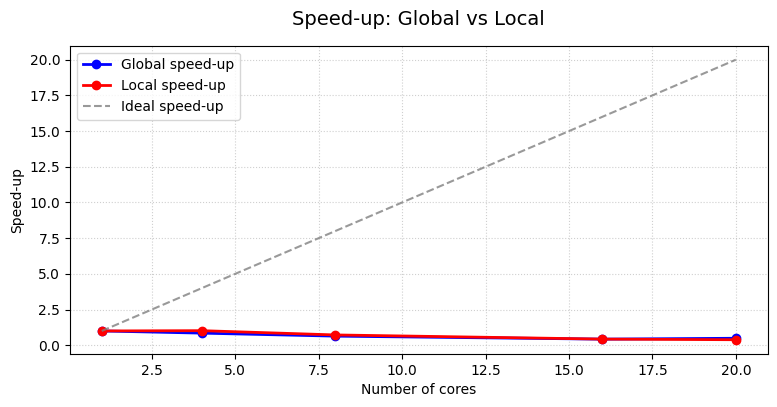

In [56]:
plot_scalability_measure('speed-up', 
                         avg_results_speedup_global, avg_results_speedup_local, 
                         'Number of cores', num_cores, num_cores)

Os resultados nos testes de **Speed-up** revelam um comportamento **predominantemente sub-linear**, em que o tempo de execução tende a aumentar com a adição de recursos. Este fenómeno é indicativo de que o volume de dados utilizado não é suficiente para saturar a capacidade computacional disponível.

O custo fixo de coordenação do Spark (agendamento de tarefas e comunicação entre nós) supera o ganho de processamento paralelo. Para este volume de dados, a latência da arquitetura distribuída é superior ao tempo de computação efetivo.

Na abordagem local, o custo de transferir dados entre a JVM e o Python intensifica este comportamento. Curiosamente, a abordagem local mostra um ganho de eficiência inicial com 4 cores, mas degrada-se rapidamente ao atingir os 8 ou mais núcleos, onde o custo de fragmentar o dataset em pequenas partições se torna prejudicial.

Concluindo, o sistema atinge o seu ponto de saturação muito cedo. A adição de mais núcleos não resulta em ganhos de performance porque o "trabalho útil" é insignificante face ao tempo gasto na orquestração do ambiente distribuído.

#

### Size-Up Global

In [57]:
for i in range(10):
    for fraction in sizes:
        !"{executable}" code/globalDT.py 8 {fraction} 10 resultados_testes_escalabilidade/teste_sizeup_global.csv
        time.sleep(2)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:54:58 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:54:58 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:54:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:54:59 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 10% | Tempo: 2.8891s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:55:12 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:57:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:57:18 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 100% | Tempo: 3.7931s                                         
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:57:31 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:57:31 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use s

25/12/30 19:59:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 19:59:32 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 75% | Tempo: 4.5444s                                          
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 19:59:48 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 19:59:48 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 19:59:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/1

25/12/30 20:01:58 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 50% | Tempo: 3.3330s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 20:02:13 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 20:02:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 20:02:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 20:02:13 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 75% | Tempo: 3.7575s
Using Spark's default log4j profile: org/apache/spa

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 20:04:35 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 20:04:35 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 20:04:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 20:04:36 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 50% | Tempo: 3.8886s                                          
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 20:04:51 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolv

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 20:06:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 20:06:59 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 25% | Tempo: 2.9046s                                          
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 20:07:13 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 20:07:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use s

### Size-Up Local

In [58]:
for i in range(10):
    for fraction in sizes:
        !"{executable}" code/localDT.py 8 {fraction} 10 resultados_testes_escalabilidade/teste_sizeup_local.csv
        time.sleep(2)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 20:08:00 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 20:08:00 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 20:08:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 20:08:01 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 10% | Tempo Total: 2.0923s                                    
Tempo médio por partição (sklearn): 0.0213s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 20:08:13 WARN

25/12/30 20:09:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 20:09:43 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 75% | Tempo Total: 2.2603s                                    
Tempo médio por partição (sklearn): 0.0824s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 20:09:54 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 20:09:54 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 20:09:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... usin

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 20:11:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 20:11:37 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 50% | Tempo Total: 2.0836s                                    
Tempo médio por partição (sklearn): 0.0463s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 20:11:47 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 20:11:47 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log le

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 20:13:25 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 20:13:25 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 20:13:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 20:13:26 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 25% | Tempo Total: 2.0611s                                    
Tempo médio por partição (sklearn): 0.0258s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 20:13:36 WARN

25/12/30 20:15:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 20:15:04 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 100% | Tempo Total: 2.1550s                                   
Tempo médio por partição (sklearn): 0.0985s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 20:15:15 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 20:15:15 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 20:15:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... usin

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 20:16:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 20:16:52 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 75% | Tempo Total: 2.1284s                                    
Tempo médio por partição (sklearn): 0.0808s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 20:17:02 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 20:17:02 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log le

### Resultados Size-Up

In [59]:
results_sizeup_global = pd.read_csv('resultados_testes_escalabilidade/teste_sizeup_global.csv', names=['cores', 'pct',
                      'runtime'])
avg_results_sizeup_global = results_sizeup_global.groupby('pct').mean()
avg_results_sizeup_global

,cores,runtime
pct,,
10,8.0,3.561579
25,8.0,3.498839
50,8.0,3.763003
75,8.0,3.823322
100,8.0,3.808905


In [60]:
avg_results_sizeup_global['size-up'] = size_up(avg_results_sizeup_global, 'runtime')
avg_results_sizeup_global[['runtime', 'size-up']]

,runtime,size-up
pct,,
10,3.561579,1.000000
25,3.498839,0.982384
50,3.763003,1.056555
75,3.823322,1.073490
100,3.808905,1.069443


In [61]:
results_sizeup_local = pd.read_csv('resultados_testes_escalabilidade/teste_sizeup_local.csv', names=['cores', 'pct',
                      'runtime', 'tempo_medio_particao'])
avg_results_sizeup_local = results_sizeup_local.groupby('pct').mean()
avg_results_sizeup_local

,cores,runtime,tempo_medio_particao
pct,,,
10,8.0,2.183766,0.012824
25,8.0,2.467187,0.057742
50,8.0,2.103951,0.049720
75,8.0,2.214172,0.081846
100,8.0,2.295164,0.110921


In [62]:
avg_results_sizeup_local['size-up'] = size_up(avg_results_sizeup_local, 'runtime')
avg_results_sizeup_local[['runtime', 'size-up']]

,runtime,size-up
pct,,
10,2.183766,1.000000
25,2.467187,1.129785
50,2.103951,0.963451
75,2.214172,1.013924
100,2.295164,1.051012


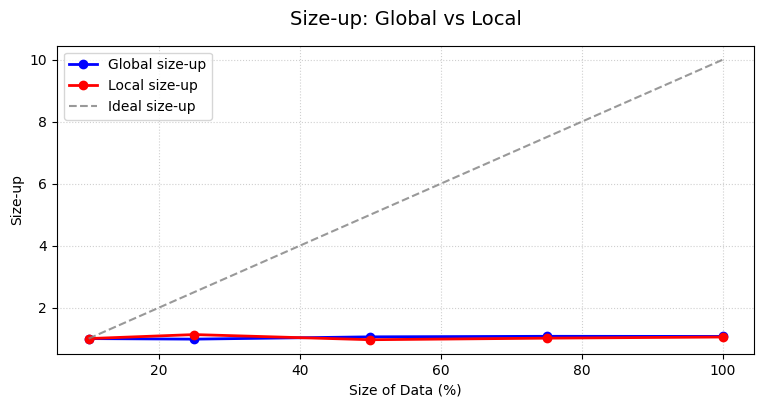

In [63]:
linear_sizeup = [1, 2.5, 5, 7.5, 10]

plot_scalability_measure('size-up', 
                         avg_results_sizeup_global, avg_results_sizeup_local, 
                         'Size of Data (%)', sizes, linear_sizeup)

Os resultados obtidos nos testes de **Size-up** revelam um comportamento **sub-linear extremamente favorável**, onde o tempo de execução cresce a um ritmo muito inferior ao crescimento do volume de dados. Enquanto a dimensão do dataset aumentou 10 vezes (de 10% para 100%), o tempo de execução na abordagem global sofreu um incremento relativamente baixo.

Este fenómeno, onde a curva real se situa muito abaixo da projeção linear teórica, explica-se pela preponderância dos Custos Fixos sobre os custos variáveis de processamento.

Até mesmo o tempo base para 10% dos dados corresponde maioritariamente ao overhead fixo do Spark (inicialização de jobs, criação de DAGs, agendamento de tarefas e latência de comunicação). O tempo efetivo de treino do modelo é uma fração pequena deste valor total.

Dado que o algoritmo de Árvore de Decisão é eficiente e o volume total de dados (150.000 instâncias) não satura a memória nem o CPU, o custo marginal de processar registos adicionais é muito baixo.

Concluindo, para esta escala de dados, a infraestrutura está sobredimensionada. O fator determinante do tempo de execução não é o processamento dos dados em si, mas sim a latência fixa da arquitetura distribuída. O sistema demonstra capacidade para absorver volumes de dados significativamente maiores antes de exibir um crescimento linear do tempo de execução.

#

### Scale-Up Global

In [64]:
for i in range(10):
    for j in range(len(num_cores)):
        !"{executable}" code/globalDT.py {num_cores[j]} {sizes[j]} 10 resultados_testes_escalabilidade/teste_scaleup_global.csv
        time.sleep(2)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 20:18:18 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 20:18:18 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 20:18:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 20:18:19 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 1 | Dados: 10% | Tempo: 2.8831s                                          
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 21:15:13 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolv

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 21:17:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 21:17:01 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 20 | Dados: 100% | Tempo: 4.5373s                                        
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 21:17:17 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 21:17:17 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use s

25/12/30 21:19:02 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 16 | Dados: 75% | Tempo: 3.4783s                                         
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 21:19:14 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 21:19:14 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 21:19:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 21:19:15 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 20 | Dados: 100% | Tempo: 6.9714s        

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 21:21:14 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 21:21:14 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 21:21:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 21:21:15 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 16 | Dados: 75% | Tempo: 3.1392s                                         
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 21:21:27 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolv

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 21:23:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 21:23:10 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 50% | Tempo: 2.7011s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 21:23:22 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 21:23:22 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use s

25/12/30 21:25:09 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 4 | Dados: 25% | Tempo: 2.0245s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 21:25:20 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 21:25:20 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 21:25:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 21:25:21 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 50% | Tempo: 2.5111s
Using Spark's default log4j profile: org/apache/spa

### Scale-Up Local

In [65]:
for i in range(10):
    for j in range(len(num_cores)):
        !"{executable}" code/localDT.py {num_cores[j]} {sizes[j]} 10 resultados_testes_escalabilidade/teste_scaleup_local.csv
        time.sleep(2)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 21:26:02 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 21:26:02 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 21:26:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 21:26:02 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 1 | Dados: 10% | Tempo Total: 1.1179s                                    
Tempo médio por partição (sklearn): 0.0402s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 21:26:12 WARN

25/12/30 21:27:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 21:27:41 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 16 | Dados: 75% | Tempo Total: 3.7917s                                   
Tempo médio por partição (sklearn): 0.0683s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 21:27:54 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 21:27:54 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 21:27:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... usin

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 21:29:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 21:29:39 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 8 | Dados: 50% | Tempo Total: 2.0681s                                    
Tempo médio por partição (sklearn): 0.0580s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 21:29:51 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 21:29:51 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log le

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 21:31:42 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 21:31:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 21:31:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 21:31:43 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 4 | Dados: 25% | Tempo Total: 1.3742s                                    
Tempo médio por partição (sklearn): 0.0317s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 21:31:52 WARN

25/12/30 21:33:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 21:33:28 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 20 | Dados: 100% | Tempo Total: 4.5807s                                  
Tempo médio por partição (sklearn): 0.1032s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 21:33:42 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 21:33:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 21:33:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... usin

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/30 21:35:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/30 21:35:30 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Cores: 16 | Dados: 75% | Tempo Total: 3.5610s                                   
Tempo médio por partição (sklearn): 0.0704s
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/30 21:35:42 WARN Utils: Your hostname, LAPTOP-MIGUEL, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/12/30 21:35:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log le

### Resultados Scale-Up

In [66]:
results_scaleup_global = pd.read_csv("resultados_testes_escalabilidade/teste_scaleup_global.csv",
    names=["cores", "pct", "runtime"])
avg_results_scaleup_global = results_scaleup_global.groupby(["cores", "pct"]).mean()
avg_results_scaleup_global

,,runtime
cores,pct,
1,10,1.969375
4,25,2.320946
8,50,2.666442
16,75,3.619712
20,100,4.551692


In [67]:
avg_results_scaleup_global['scale-up'] = scale_up(avg_results_scaleup_global, 'runtime')
avg_results_scaleup_global[['runtime', 'scale-up']]

,,runtime,scale-up
cores,pct,,
1,10,1.969375,1.000000
4,25,2.320946,0.848523
8,50,2.666442,0.738578
16,75,3.619712,0.544070
20,100,4.551692,0.432669


In [68]:
results_scaleup_local = pd.read_csv("resultados_testes_escalabilidade/teste_scaleup_local.csv",
    names=["cores", "pct", "runtime", 'tempo_medio_particao'])
avg_results_scaleup_local = results_scaleup_local.groupby(["cores", "pct"]).mean()
avg_results_scaleup_local

,,runtime,tempo_medio_particao
cores,pct,,
1,10,1.170502,0.042403
4,25,1.431380,0.033190
8,50,2.369132,0.056862
16,75,3.845268,0.081120
20,100,5.082145,0.101995


In [69]:
avg_results_scaleup_local['scale-up'] = scale_up(avg_results_scaleup_local, 'runtime')
avg_results_scaleup_local[['runtime', 'scale-up']]

,,runtime,scale-up
cores,pct,,
1,10,1.170502,1.000000
4,25,1.431380,0.817744
8,50,2.369132,0.494064
16,75,3.845268,0.304401
20,100,5.082145,0.230317


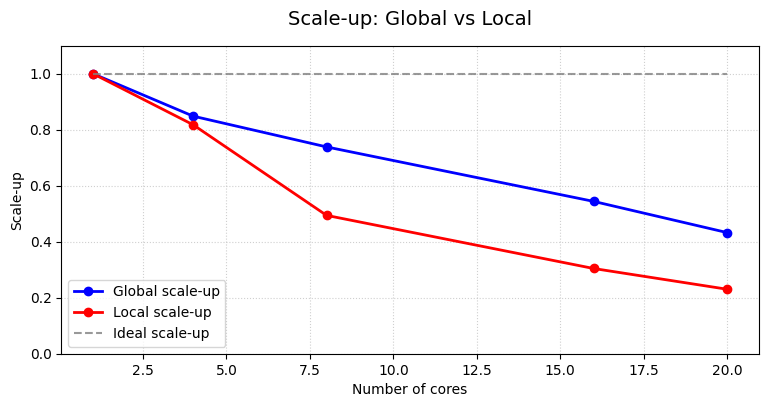

In [70]:
ideal_scaleup = [1] * 5

plot_scalability_measure('scale-up', 
    avg_results_scaleup_global, avg_results_scaleup_local, 
    'Number of cores', num_cores, ideal_scaleup)

Os testes de **Scale-up** revelam uma **degradação progressiva da eficiência** à medida que se aumenta simultaneamente o número de núcleos e o volume de dados. Enquanto o cenário ideal previa uma eficiência constante de 1.0, observou-se uma queda significativa de performance em ambas abordagens ao atingir os 20 núcleos e 100% dos dados.

O tempo ganho ao distribuir o aumento da carga de trabalho foi anulado pelo overhead de gestão do Spark. Como o tempo médio de processamento por partição é extremamente baixo, o sistema gasta mais tempo na orquestração do que na computação efetiva.

A abordagem Local apresenta uma descida mais acentuada devido ao custo acumulado de serialização entre a JVM e o Python em cada uma das 20 partições.

Concluindo, o sistema demonstra escalabilidade limitada para este volume de dados, indicando que o benefício do paralelismo massivo só seria visível com um dataset significativamente maior, capaz de diluir os custos fixos da arquitetura distribuída.

### Impacto de Caching e Número de Partições

Durante o desenvolvimento, aplicou-se a persistência em memória (`.cache()`) nos DataFrames após a fase de limpeza e antes da fase de treino dos modelos. Esta estratégia revelou-se crucial, pois o treino dos modelos de Machine Learning (Global e Local) envolve múltiplas passagens pelos mesmos dados. Sem o uso de cache, o Spark seria forçado a re-executar todo o pipeline de pré-processamento para cada iteração do algoritmo, aumentando drasticamente o tempo de execução.

Relativamente ao particionamento, observou-se que a performance está intrinsecamente ligada ao número de partições. Nos testes com 1 e 4 núcleos, a carga estava equilibrada. Contudo, com 20 núcleos, a fragmentação dos dados em 20 partições revelou-se excessiva. O tempo médio de processamento por partição baixou para menos de 0.1s, tornando o custo de gestão de partições pelo Driver o principal fator de latência, o que justifica os resultados dos testes de escalabilidade sub-lineares observados.

#

# Conclusões Finais

O presente trabalho permitiu a exploração aprofundada das capacidades do **Apache Spark** no processamento distribuído de dados, através da implementação de modelos de classificação globais e locais. A arquitetura desenvolvida demonstrou ser robusta e capaz de lidar com todas as fases do pipeline de Ciência de Dados, desde o pré-processamento até à avaliação de escalabilidade.

É importante salientar que, na fase inicial do projeto, foi testado um dataset alternativo composto por **mais de 2 milhões de instâncias**. Esse dataset apresentava resultados significativamente superiores nos testes de escalabilidade, uma vez que o elevado volume de dados permitia diluir o overhead de coordenação do Spark e saturar os recursos computacionais de forma eficiente. Além disso, por ser um dataset nativamente balanceado, as métricas de previsão revelavam-se mais promissoras.

No entanto, optou-se deliberadamente pela transição para o dataset de risco de crédito atual (150.000 instâncias). Apesar de este apresentar desafios acrescidos, como o **acentuado desbalanceamento entre classes** e a necessidade de um **pré-processamento e limpeza de dados mais exaustivos**, considerou-se que esta escolha oferecia uma hipótese mais favorável para aplicar conhecimentos adquiridos nesta unidade curricular. A resolução de problemas reais de limpeza, a análise crítica de modelos enviesados pela classe maioritária e a compreensão dos limites do paralelismo em datasets de média escala foram fundamentais para a consolidação da aprendizagem.

Os resultados de escalabilidade obtidos, embora sub-lineares devido ao peso relativo da orquestração do ambiente distribuído face ao tempo de computação, são tecnicamente coerentes e justificáveis. A estabilidade demonstrada nos testes de Size-up confirma que a solução desenvolvida é escalável em termos de volume de dados, estando preparada para cenários de produção com maior carga de trabalho. Em suma, o projeto cumpriu os seus objetivos pedagógicos, demonstrando que a eficácia de uma solução de Big Data reside não apenas nos seus resultados finais, mas na capacidade em compreender e otimizar cada etapa do processo distribuído.

#
#
#

# Extra

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from copy import deepcopy

from sklearn.model_selection import GridSearchCV, GroupShuffleSplit, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, Normalizer, FunctionTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier as SklearnDT

In [72]:
# Setting para dar display das tabelas sem omitir dados das colunas
pd.set_option('display.max_colwidth', None)

In [73]:
train_pd = train_df.toPandas()
test_pd = test_df.toPandas()
#display(train_pd.head(2))

In [74]:
X_train = train_pd.drop(columns=["Label", "weight"])
y_train = train_pd["Label"]
#display(X_train.head(2))

X_test = test_pd.drop(columns=["Label", "weight"])
y_test = test_pd["Label"]
#display(X_test.head(2))

In [75]:
# Inicia a list para todos os melhores modelos e métricas de cada método e os seus nomes
melhores_modelos = []
melhores_modelos_names = []
melhores_f1_val = []
melhor_f1_train = []    
melhores_overfitting = []

In [76]:
# Função responsável pela construção e avaliação do modelo ### REMOVER IMPORTÂNCIAS NÃO SIGNIFICATIVAS ###
def modelo(metodo, string_metodo, params_grid, scaler=None): # importancia_features=False, threshold=0.05
    string_pipeline = string_metodo

    if scaler is None:
        scaler = FunctionTransformer(lambda x: x)

    pipeline = Pipeline([
        ('scaler', scaler),
        (string_pipeline, metodo)
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=params_grid,
        cv=skf,
        scoring="f1",
        n_jobs=-1,
        return_train_score=True
    )
    grid_search.fit(X_train, y_train)

    # Melhor modelo
    melhor_modelo = grid_search.best_estimator_

    # Arrays para a tabela final:
    # Índice da melhor combinação
    melhor_indice = grid_search.best_index_
    # Extrair métricas do melhor
    melhor_mean_train = grid_search.cv_results_['mean_train_score'][melhor_indice]
    melhor_mean_val = grid_search.cv_results_['mean_test_score'][melhor_indice]
    melhor_overfit = melhor_mean_train - melhor_mean_val

    melhores_modelos_names.append(string_metodo)
    melhores_modelos.append(melhor_modelo)
    melhores_f1_val.append(grid_search.best_score_)
    melhor_f1_train.append(melhor_mean_train)
    melhores_overfitting.append(melhor_overfit)

    print("Melhores parâmetros:", grid_search.best_params_)
    print(f"Melhor F1 (Val): {melhores_f1_val[-1]:.2f}")

    resultados_df = pd.DataFrame(grid_search.cv_results_)
    resultados_df = resultados_df[["params", "mean_train_score", "mean_test_score", "rank_test_score"]]
    resultados_df["overfitting"] = (resultados_df["mean_train_score"] - resultados_df["mean_test_score"])
    resultados_df = resultados_df.sort_values(by="rank_test_score")

    display(resultados_df.head())
    
    return melhor_modelo

In [77]:
def display_classification_report(metodo, X, y, valor=0.5):
    y_probs = metodo.predict_proba(X)[:,1]
    y_pred = (y_probs >= valor).astype(int)
    
    report_dict = classification_report(y, y_pred, target_names=['0', '1'], output_dict=True, zero_division=0)

    df = pd.DataFrame(report_dict).T
    df = df.loc[['0', '1', 'accuracy'], ['precision', 'recall', 'f1-score']].round(2)
    df = df.rename(index={'accuracy': 'Exatidão'}, columns={'precision': 'Precisão', 'recall': 'Cobertura','f1-score': 'F1-Score'
    })

    return df

In [78]:
def matriz_confusao(modelo, X_test, y_test, nome_modelo, valor=0.5):
    # Previsões
    y_pred = modelo.predict_proba(X_test)[:,1]
    y_pred = (y_pred >= valor).astype(int)
    
    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    
    # Exibição
    plt.figure(figsize=(10, 3))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
    disp.plot(cmap="Purples", ax=plt.gca())
        
    plt.xlabel("Predição")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusão — {nome_modelo}")
    plt.show()

In [79]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [80]:
dt = SklearnDT(class_weight='balanced', random_state=0)

In [81]:
params_grid_dt = {
    "dt__max_depth": [3, 5, 7, 10],
    "dt__criterion": ["gini", "entropy"],
    "dt__min_samples_leaf": [1, 5, 20],
    "dt__min_impurity_decrease": [0.0, 0.001, 0.01]
}

In [82]:
melhor_modelo_dt = modelo(dt, 'dt', params_grid_dt, scaler=None)

Melhores parâmetros: {'dt__criterion': 'entropy', 'dt__max_depth': 7, 'dt__min_impurity_decrease': 0.001, 'dt__min_samples_leaf': 1}
Melhor F1 (Val): 0.33


,params,mean_train_score,mean_test_score,rank_test_score,overfitting
57,"{'dt__criterion': 'entropy', 'dt__max_depth': 7, 'dt__min_impurity_decrease': 0.001, 'dt__min_samples_leaf': 1}",0.33117,0.326073,1,0.005097
58,"{'dt__criterion': 'entropy', 'dt__max_depth': 7, 'dt__min_impurity_decrease': 0.001, 'dt__min_samples_leaf': 5}",0.33117,0.326073,1,0.005097
59,"{'dt__criterion': 'entropy', 'dt__max_depth': 7, 'dt__min_impurity_decrease': 0.001, 'dt__min_samples_leaf': 20}",0.33117,0.326073,1,0.005097
67,"{'dt__criterion': 'entropy', 'dt__max_depth': 10, 'dt__min_impurity_decrease': 0.001, 'dt__min_samples_leaf': 5}",0.33117,0.326073,1,0.005097
66,"{'dt__criterion': 'entropy', 'dt__max_depth': 10, 'dt__min_impurity_decrease': 0.001, 'dt__min_samples_leaf': 1}",0.33117,0.326073,1,0.005097


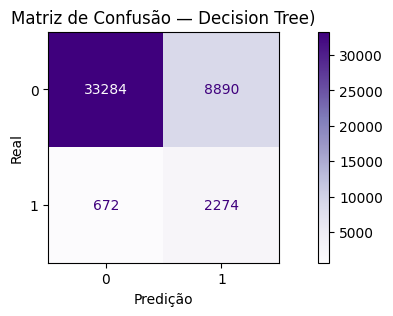

,Precisão,Cobertura,F1-Score
0,0.98,0.79,0.87
1,0.20,0.77,0.32
Exatidão,0.79,0.79,0.79


In [84]:
matriz_confusao(melhor_modelo_dt, X_test, y_test, 'Decision Tree)')
display(display_classification_report(melhor_modelo_dt, X_test, y_test))